<div align="center">

# Práctica 2B — PCA para preprocesar datos

## **Manejo y Procesamiento de la Información**

---

**Estudiante:** Chanona Leyva José Luis  
**Profesor:** Dr. Luis Guillermo Ruiz Velázquez  
**Fecha de elaboración:** 6 de octubre de 2026

</div>

# Información

El análisis de componentes principales (PCA) es una técnica que transforma un conjunto de variables en un número menor de componentes. Estos componentes conservan la mayor cantidad posible de variabilidad de los datos.

PCA puede utilizarse como parte del preprocesamiento antes de aplicar un algoritmo de clustering. En este ejercicio se analizará si reducir la dimensión de las imágenes MNIST modifica la calidad de los grupos encontrados por K-means.

# Objetivo

Comparar la calidad de los clusters obtenidos con K-means antes y después de aplicar PCA al conjunto MNIST, utilizando la métrica `rand_score`.

Se realizarán dos experimentos:

1. Usar únicamente las clases 0 y 1, reducir a dos componentes y visualizar los datos.
2. Aumentar progresivamente el número de clases de 2 a 10 y reducir la dimensión a 50 componentes.

# Actividad

1. Leer el conjunto MNIST desde OpenML.
2. Usar las imágenes con ceros y unos, aplicar `StandardScaler`, PCA a dos dimensiones y graficar las clases.
3. Aplicar K-means con `random_state=1` antes y después de PCA y comparar con `rand_score`.
4. Repetir el análisis para 2 a 10 clases, aplicando PCA a 50 componentes.

# Metodología y decisiones reproducibles

- MNIST contiene 784 variables por imagen, una por cada píxel.
- Se aplica `StandardScaler` antes de PCA y antes de K-means, tal como solicita la actividad.
- Se utiliza `random_state=1` en K-means y PCA para que los resultados puedan reproducirse.
- `rand_score` compara las etiquetas reales con las etiquetas asignadas. Un valor cercano a 1 indica mayor coincidencia entre ambas particiones.
- En el segundo experimento se utiliza una muestra balanceada de hasta 300 imágenes por clase. Esta decisión evita que el ciclo completo exceda la memoria disponible y mantiene el mismo número de imágenes por clase. El parámetro puede cambiarse a `None` en un entorno con recursos suficientes para intentar usar todas las imágenes.

# Preparación del entorno

In [1]:
# Importamos NumPy para trabajar con matrices y realizar operaciones numéricas.
import numpy as np

# Importamos Pandas para presentar los resultados comparativos en tablas.
import pandas as pd

# Importamos Matplotlib para construir las gráficas de las clases y las métricas.
import matplotlib.pyplot as plt

# Cargamos MNIST directamente desde OpenML, como solicita la actividad.
from sklearn.datasets import fetch_openml

# StandardScaler centra y escala las variables antes del análisis.
from sklearn.preprocessing import StandardScaler

# PCA reduce el número de dimensiones conservando la mayor variabilidad posible.
from sklearn.decomposition import PCA

# KMeans crea los grupos a partir de las distancias entre observaciones.
from sklearn.cluster import KMeans

# rand_score compara las etiquetas reales con las etiquetas de los clusters.
from sklearn.metrics import rand_score

# Fijamos una semilla para seleccionar siempre la misma muestra balanceada.
RANDOM_STATE = 1

# Aplicamos un estilo consistente y legible a las gráficas.
plt.style.use("seaborn-v0_8-whitegrid")

# Lectura y validación de MNIST

In [2]:
# Descargamos las imágenes y sus etiquetas desde OpenML.
X, y = fetch_openml("mnist_784", return_X_y=True, as_frame=False)

# Convertimos las imágenes a float32 para reducir el consumo de memoria.
X = X.astype(np.float32)

# Convertimos las etiquetas de texto a enteros para filtrar las clases.
y = y.astype(int)

# Verificamos la forma general del conjunto de datos.
print(f"Número total de imágenes: {X.shape[0]:,}")
print(f"Número de variables por imagen: {X.shape[1]:,}")
print(f"Clases disponibles: {np.unique(y)}")

# Comprobamos que el número de etiquetas corresponda al número de imágenes.
if X.shape[0] != y.shape[0]:
    raise ValueError("El número de imágenes y etiquetas no coincide.")

# Confirmamos que no existan valores no finitos en la matriz.
if not np.isfinite(X).all():
    raise ValueError("Las imágenes contienen valores NaN o infinitos.")

Número total de imágenes: 70,000
Número de variables por imagen: 784
Clases disponibles: [0 1 2 3 4 5 6 7 8 9]


# 1. Clases 0 y 1 con PCA a dos dimensiones

Primero se conservarán todas las imágenes cuyas etiquetas sean 0 o 1. Después se aplicará `StandardScaler` y se generará una representación de dos componentes para visualizar la separación de las clases.

In [3]:
# Creamos una máscara que identifica únicamente las imágenes de las clases 0 y 1.
mascara_01 = np.isin(y, [0, 1])

# Aplicamos la máscara a las imágenes y a sus etiquetas verdaderas.
X_01 = X[mascara_01]
y_01 = y[mascara_01]

# Creamos el escalador que centrará cada píxel y lo dividirá entre su desviación estándar.
escalador_01 = StandardScaler()

# Ajustamos el escalador con los datos de 0 y 1 y transformamos las imágenes.
X_01_escalado = escalador_01.fit_transform(X_01)

# Creamos PCA con dos componentes para obtener coordenadas graficables.
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE, svd_solver="randomized")

# Ajustamos PCA y proyectamos las imágenes en dos dimensiones.
X_01_pca_2 = pca_2.fit_transform(X_01_escalado)

# Reportamos el tamaño del subconjunto y la variabilidad conservada.
print(f"Imágenes de las clases 0 y 1: {X_01.shape[0]:,}")
print(f"Dimensiones después de PCA: {X_01_pca_2.shape[1]}")
print(f"Varianza explicada por PCA: {pca_2.explained_variance_ratio_.sum():.2%}")

Imágenes de las clases 0 y 1: 14,780
Dimensiones después de PCA: 2
Varianza explicada por PCA: 22.65%


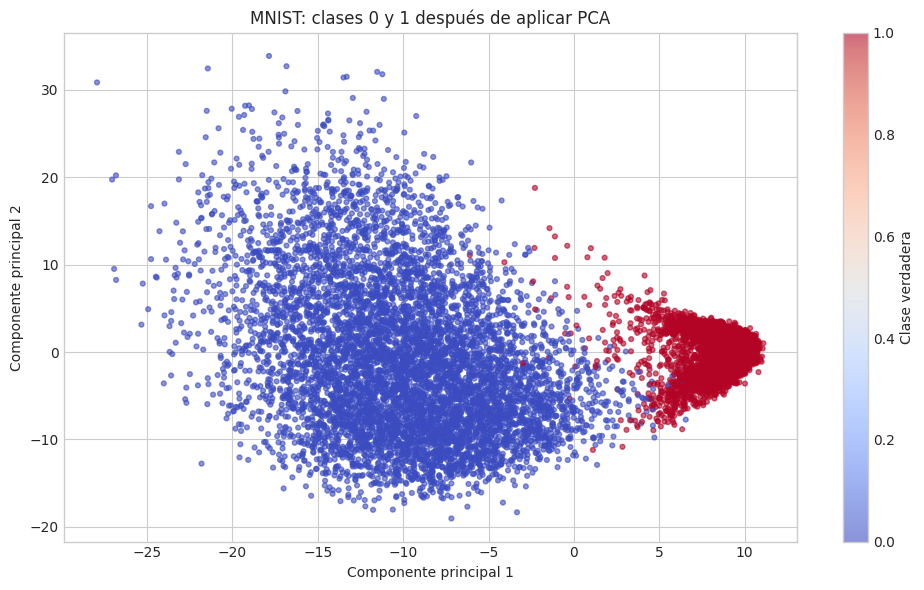

In [4]:
# Creamos una figura para visualizar la posición de cada imagen después de PCA.
plt.figure(figsize=(10, 6))

# Dibujamos los puntos y usamos el color para representar la clase verdadera.
plt.scatter(
    X_01_pca_2[:, 0],
    X_01_pca_2[:, 1],
    c=y_01,
    cmap="coolwarm",
    s=12,
    alpha=0.60,
)

# Agregamos título, ejes y barra de color para interpretar el gráfico.
plt.title("MNIST: clases 0 y 1 después de aplicar PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Clase verdadera")
plt.tight_layout()
plt.show()

### Interpretación de la visualización

Cada punto representa una imagen. Los colores muestran la etiqueta real: rojo para una clase y azul para la otra. La distancia entre las nubes de puntos permite observar visualmente qué tan fácil sería separar ambas clases en el espacio reducido.

## K-means antes y después de PCA

Se entrenarán dos modelos con `k=2`:

- uno con las 784 variables escaladas;
- otro con las dos componentes principales.

Después se compararán sus etiquetas contra las clases reales mediante `rand_score`.

In [5]:
# Creamos K-means para trabajar con las 784 variables escaladas originales.
kmeans_01_original = KMeans(n_clusters=2, random_state=1, n_init=10)

# Ajustamos el modelo y obtenemos una etiqueta de cluster para cada imagen.
etiquetas_01_original = kmeans_01_original.fit_predict(X_01_escalado)

# Creamos K-means para trabajar con las dos componentes principales.
kmeans_01_pca = KMeans(n_clusters=2, random_state=1, n_init=10)

# Ajustamos el segundo modelo y obtenemos sus etiquetas.
etiquetas_01_pca = kmeans_01_pca.fit_predict(X_01_pca_2)

# Comparamos cada resultado con las etiquetas reales de MNIST.
rand_01_original = rand_score(y_01, etiquetas_01_original)
rand_01_pca = rand_score(y_01, etiquetas_01_pca)

# Organizamos la comparación en una tabla clara.
comparacion_01 = pd.DataFrame({
    "representación": ["784 variables escaladas", "2 componentes PCA"],
    "rand_score": [rand_01_original, rand_01_pca],
})

# Mostramos los valores redondeados para facilitar su lectura.
display(comparacion_01.assign(rand_score=comparacion_01["rand_score"].round(4)))

,representación,rand_score
0,784 variables escaladas,0.9792
1,2 componentes PCA,0.9737


### Interpretación del experimento con 0 y 1

El modelo con el valor de `rand_score` más alto reproduce mejor la separación real entre las clases 0 y 1. La comparación permite observar si la reducción a dos dimensiones conserva suficiente información para que K-means mantenga una calidad similar a la obtenida con las 784 variables.

# 2. De 2 a 10 clases con PCA a 50 dimensiones

Ahora se repetirá el análisis aumentando progresivamente el número de clases. Para cada valor se selecciona una muestra balanceada, se escalan los datos, se aplica K-means con y sin PCA y se calcula `rand_score`.

In [6]:
# Indicamos cuántas imágenes como máximo se tomarán de cada clase en el ciclo.
MUESTRAS_POR_CLASE = 300

# Creamos un generador reproducible para elegir siempre las mismas imágenes.
generador = np.random.default_rng(RANDOM_STATE)


def seleccionar_muestra_balanceada(X, y, clases, muestras_por_clase, generador):
    """Devuelve el mismo número de imágenes por cada clase seleccionada."""

    # Esta lista almacenará los índices elegidos para todas las clases.
    indices_seleccionados = []

    # Recorremos cada clase que debe formar parte del experimento.
    for clase in clases:
        # Localizamos las posiciones de las imágenes pertenecientes a la clase actual.
        indices_clase = np.flatnonzero(y == clase)

        # Usamos todas las imágenes disponibles o una muestra fija, según el parámetro.
        if muestras_por_clase is None:
            indices_elegidos = indices_clase
        else:
            cantidad = min(muestras_por_clase, len(indices_clase))
            indices_elegidos = generador.choice(
                indices_clase,
                size=cantidad,
                replace=False,
            )

        # Agregamos los índices de la clase actual a la selección final.
        indices_seleccionados.append(indices_elegidos)

    # Unimos los índices de todas las clases en un solo arreglo.
    indices_seleccionados = np.concatenate(indices_seleccionados)

    # Devolvemos las imágenes y etiquetas seleccionadas.
    return X[indices_seleccionados], y[indices_seleccionados]

In [7]:
# Creamos listas para guardar los resultados de cada cantidad de clases.
resultados = []

# Probamos desde dos clases hasta las diez clases de MNIST.
for numero_clases in range(2, 11):
    # Definimos las clases que se incluirán en la iteración actual.
    clases_actuales = np.arange(numero_clases)

    # Seleccionamos la misma cantidad de imágenes para cada clase.
    X_actual, y_actual = seleccionar_muestra_balanceada(
        X,
        y,
        clases_actuales,
        MUESTRAS_POR_CLASE,
        generador,
    )

    # Creamos un escalador independiente para cada conjunto de clases.
    escalador = StandardScaler()

    # Estandarizamos las 784 variables antes de entrenar los modelos.
    X_actual_escalado = escalador.fit_transform(X_actual)

    # Entrenamos K-means directamente con las variables escaladas.
    modelo_original = KMeans(
        n_clusters=numero_clases,
        random_state=1,
        n_init=10,
    )
    etiquetas_originales = modelo_original.fit_predict(X_actual_escalado)

    # Reducimos la representación a 50 componentes principales.
    pca_50 = PCA(
        n_components=50,
        random_state=RANDOM_STATE,
        svd_solver="randomized",
    )
    X_actual_pca = pca_50.fit_transform(X_actual_escalado)

    # Entrenamos K-means con la representación reducida por PCA.
    modelo_pca = KMeans(
        n_clusters=numero_clases,
        random_state=1,
        n_init=10,
    )
    etiquetas_pca = modelo_pca.fit_predict(X_actual_pca)

    # Medimos la coincidencia entre las clases reales y cada agrupamiento.
    rand_original = rand_score(y_actual, etiquetas_originales)
    rand_pca = rand_score(y_actual, etiquetas_pca)

    # Guardamos las métricas y el porcentaje de varianza conservada por PCA.
    resultados.append({
        "número de clases": numero_clases,
        "imágenes utilizadas": len(y_actual),
        "rand_score sin PCA": rand_original,
        "rand_score con PCA": rand_pca,
        "varianza explicada por PCA": pca_50.explained_variance_ratio_.sum(),
    })

    # Liberamos matrices grandes antes de comenzar la siguiente iteración.
    del X_actual, y_actual, X_actual_escalado, X_actual_pca

# Convertimos los resultados en una tabla para analizarlos y graficarlos.
resultados = pd.DataFrame(resultados)
display(resultados.round(4))

,número de clases,imágenes utilizadas,rand_score sin PCA,rand_score con PCA,varianza explicada por PCA
0,2,600,0.9769,0.9769,0.8605
1,3,900,0.9009,0.8984,0.7682
2,4,1200,0.8751,0.8795,0.7516
3,5,1500,0.8799,0.8820,0.6960
4,6,1800,0.8566,0.8582,0.6797
5,7,2100,0.8442,0.8487,0.6668
6,8,2400,0.8771,0.8606,0.6490
7,9,2700,0.8447,0.8481,0.6459
8,10,3000,0.8555,0.8603,0.6434


### Interpretación de la tabla

La tabla permite comparar, para cada número de clases, el desempeño de K-means con las 784 variables escaladas y con las 50 componentes de PCA. La columna de varianza explicada indica qué proporción de la información original se conserva en la representación reducida.

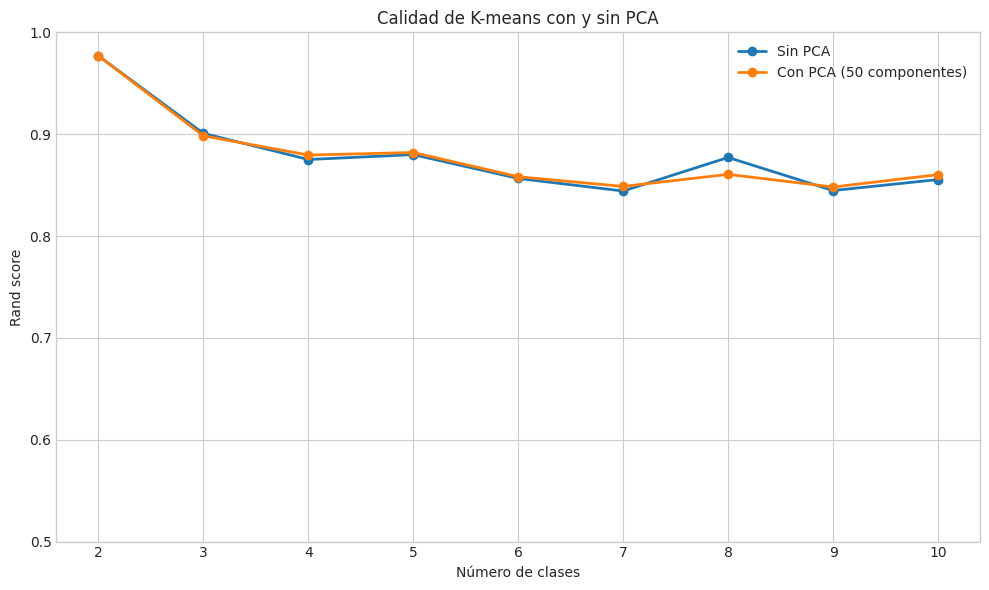

In [8]:
# Creamos una figura para comparar ambas versiones de K-means.
plt.figure(figsize=(10, 6))

# Graficamos el rand_score cuando no se utiliza PCA.
plt.plot(
    resultados["número de clases"],
    resultados["rand_score sin PCA"],
    marker="o",
    linewidth=2,
    label="Sin PCA",
)

# Graficamos el rand_score cuando se utilizan 50 componentes de PCA.
plt.plot(
    resultados["número de clases"],
    resultados["rand_score con PCA"],
    marker="o",
    linewidth=2,
    label="Con PCA (50 componentes)",
)

# Añadimos los elementos necesarios para interpretar la comparación.
plt.title("Calidad de K-means con y sin PCA")
plt.xlabel("Número de clases")
plt.ylabel("Rand score")
plt.xticks(range(2, 11))
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Calculamos la diferencia entre utilizar PCA y conservar las 784 variables.
# Un valor positivo significa que PCA mejoró el rand_score.
resultados["cambio por PCA"] = (
    resultados["rand_score con PCA"]
    - resultados["rand_score sin PCA"]
)

# Contamos en cuántas configuraciones PCA produjo una mejora.
mejoras = (resultados["cambio por PCA"] > 0).sum()

# Seleccionamos la fila donde el incremento del rand_score fue más grande.
fila_mayor_mejora = resultados.loc[resultados["cambio por PCA"].idxmax()]

# Guardamos el número de clases seleccionado para utilizarlo en la interpretación.
numero_clases_mejor_pca = int(fila_mayor_mejora["número de clases"])

# Guardamos el tamaño de la mejora para reportarlo con precisión.
mejora_maxima = fila_mayor_mejora["cambio por PCA"]

# También identificamos el mejor rand_score absoluto obtenido con PCA.
fila_mejor_puntaje_pca = resultados.loc[resultados["rand_score con PCA"].idxmax()]

# Mostramos la selección solicitada: las clases donde PCA mejoró más el clustering.
print(f"PCA mejoró el rand_score en {mejoras} de {len(resultados)} configuraciones.")
print(
    f"La mayor mejora se obtuvo con {numero_clases_mejor_pca} clases: "
    f"{mejora_maxima:+.4f} puntos de rand_score."
)
print(
    "El mejor rand_score absoluto con PCA fue "
    f"{fila_mejor_puntaje_pca['rand_score con PCA']:.4f} "
    f"con {int(fila_mejor_puntaje_pca['número de clases'])} clases."
)

PCA mejoró el rand_score en 6 de 9 configuraciones.
La mayor mejora se obtuvo con 10 clases: +0.0048 puntos de rand_score.
El mejor rand_score absoluto con PCA fue 0.9769 con 2 clases.


# Conclusiones

PCA permitió reducir la representación de las imágenes sin eliminar por completo la información útil para K-means. Los resultados obtenidos fueron los siguientes:

- Para las clases 0 y 1, K-means obtuvo `rand_score = 0.9792` con las 784 variables escaladas y `rand_score = 0.9737` después de reducir a dos componentes. La reducción a dos dimensiones facilita la visualización, aunque produjo una disminución pequeña de la métrica.
- En el segundo experimento se utilizaron 300 imágenes por clase para mantener una muestra balanceada y permitir la ejecución del ciclo completo. PCA mejoró el `rand_score` en 6 de las 9 configuraciones evaluadas.
- Al comparar el cambio de métrica, la mayor mejora al aplicar PCA con 50 componentes se obtuvo con **10 clases**, con un incremento de aproximadamente `0.0048` puntos de `rand_score` (`0.8603` con PCA frente a `0.8555` sin PCA).
- El mejor `rand_score` absoluto con PCA fue `0.9769` para 2 clases. Este resultado es diferente de la mayor mejora: una cosa es obtener el valor más alto y otra es mejorar más respecto al modelo sin PCA.
- La varianza explicada por las 50 componentes disminuyó de `86.05%` con 2 clases a `64.34%` con 10 clases. Esto muestra que una misma cantidad de componentes conserva una proporción menor de información cuando aumenta la variedad de clases.

Por lo tanto, el número de clases seleccionado por presentar la **mayor mejora relativa al aplicar PCA** es **10 clases**. PCA resulta útil porque reduce la dimensión y, en varias configuraciones, conserva o mejora la calidad del clustering.

# Referencias

- scikit-learn developers. (s. f.). *fetch_openml*. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
- scikit-learn developers. (s. f.). *StandardScaler*. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- scikit-learn developers. (s. f.). *PCA*. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- scikit-learn developers. (s. f.). *KMeans*. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- scikit-learn developers. (s. f.). *rand_score*. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html